In [1]:
%cd /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough

import argparse, inspect, json, os, pickle, socket, subprocess, warnings, random, math, librosa, shutil
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import lightning as L
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers.tensorboard import TensorBoardLogger
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

import commons, models, utils, losses
from cough_datasets import CoughDatasets, CoughDatasetsCollate

torch.set_float32_matmul_precision("medium")
cmap = cm.get_cmap("viridis")

parser = argparse.ArgumentParser()
parser.add_argument("--init", action="store_true")
parser.add_argument("--model_name", type=str, default="try_wavlmlora_downstream")
parser.add_argument("--config_path", type=str, default="configs/ssl_finetuning.json")
args = parser.parse_args(["--model_name", "wavlmencoder_scl_attentive", "--config_path", "general.json"])

model_dir = os.path.join("./logs", args.model_name)

config_save_path = os.path.join(model_dir, "config.json")
if args.init:
    with open(args.config_path, "r") as f:
        data = f.read()
    with open(config_save_path, "w") as f:
        f.write(data)
else:
    with open(config_save_path, "r") as f:
        data = f.read()
config = json.loads(data)

hps = utils.HParams(**config)
hps.model_dir = model_dir
hps.data.mae_training = hps.train.mae_training

df_train = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/{hps.data.metadata_csv}.train')
df_test = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/{hps.data.metadata_csv}.test')

#df_train = df_train[~df_train['db'].isin([0, 1])]

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train = df_train[hps.data.column_order + ['db']]
df_test = df_test[hps.data.column_order + ['db']]

collate_fn = CoughDatasetsCollate(hps.data.many_class)

class CoughDetectionRunner(L.LightningModule):
    def __init__(self, model, hps, class_weights=[]):
        super().__init__()
        self.model = model
        self.hps = hps
        self.class_weights = class_weights

        self.supcon_loss = losses.SupConLoss()

        #ckpt = torch.load("/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/pretrained/encoder-operaGT.ckpt")
        #self.model.load_state_dict(ckpt["state_dict"], strict=False)

        if hps.model.pooling_model.split("_")[0] == "WavLMEncoder":
            from transformers import AutoModel
            ssl_model = AutoModel.from_pretrained("microsoft/wavlm-large")
            self.model.feature_extractor.load_state_dict(ssl_model.feature_extractor.state_dict())
            self.model.feature_extractor._freeze_parameters()

            del ssl_model
            torch.cuda.empty_cache()

    def forward(self, x1, x2, attention_mask=None):
        x = self.model(x1, x2=x2, attention_mask=attention_mask)
        return x
    
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hps.train.learning_rate)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=2)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val/loss",
            },
        }

    def on_after_backward(self):
        norm_type = 2
        total_norm = 0
        parameters = list(filter(lambda p: p.grad is not None, self.model.parameters()))
        for p in parameters:
            param_norm = p.grad.data.norm(norm_type)
            total_norm += param_norm.item() ** norm_type
        total_norm = total_norm ** (1. / norm_type)
        self.log("train/grad_norm", total_norm, sync_dist=True)

    def training_step(self, batch, batch_idx):
        _, audio1, audio2, attention_masks, dse_ids, _ = batch
        out_model = self.forward(audio1, audio2, attention_mask=attention_masks)

        tot_loss = []
        if "disease_logits" in out_model:
            ld = utils.many_loss_category(out_model["disease_logits"], dse_ids, loss_type=self.hps.train.loss_function, weights=self.class_weights)
            tot_loss.append(ld[0])

        if "loss" in out_model:
            tot_loss.append(out_model["loss"])

        if "embedding" in out_model:
            tot_loss.append(self.supcon_loss(out_model["embedding"], dse_ids))

        loss = sum(tot_loss)
        for idx_loss, now_loss in enumerate(tot_loss):
            self.log(f"train/loss_{idx_loss}", now_loss, on_step=True, on_epoch=False, prog_bar=False, logger=True)

        self.log("train/loss_step", loss, on_step=True, on_epoch=False, prog_bar=True, logger=True)
        self.logger.experiment.add_scalars('loss', {'train': loss}, self.global_step)

        if "pred" in out_model:
            random_idx = torch.randint(0, out_model["pred"].size(0), (1,)).item()
            
            self.logger.experiment.add_image(
                "pred_image",
                utils.plot_spectrogram_to_numpy(out_model["pred"][random_idx].data.cpu().numpy().T),
                global_step=self.global_step
            )

            self.logger.experiment.add_image(
                "orig_image",
                utils.plot_spectrogram_to_numpy(audio1[random_idx].data.cpu().numpy()),
                global_step=self.global_step
            )

        return loss

    def on_train_batch_end(self, outputs, batch, batch_idx):
        lr = self.optimizers().param_groups[0]["lr"]
        self.log("train/lr", lr, sync_dist=True)

    def validation_step(self, batch, batch_idx):
        _, audio1, audio2, attention_masks, dse_ids, _ = batch
        out_model = self.forward(audio1, audio2, attention_mask=attention_masks)
        
        tot_loss = []
        if "disease_logits" in out_model:
            ld = utils.many_loss_category(out_model["disease_logits"], dse_ids, loss_type=self.hps.train.loss_function, weights=self.class_weights)
            tot_loss.append(ld[0])

        if "loss" in out_model:
            tot_loss.append(out_model["loss"])

        if "embedding" in out_model:
            tot_loss.append(self.supcon_loss(out_model["embedding"], dse_ids))

        loss = sum(tot_loss)
        self.logger.experiment.add_scalars('loss', {'valid': loss}, self.global_step)
        self.log("val/loss", loss, on_step=False, on_epoch=True, prog_bar=False, logger=True)

    def on_test_epoch_start(self):
        self.test_preds = []
        self.test_labels = []

    def test_step(self, batch, batch_idx):
        _, audio1, audio2, attention_masks, dse_ids, _ = batch
        dse_ids = dse_ids.float()
        logits = self.forward(audio1, audio2, attention_mask=attention_masks)["disease_logits"]
        
        preds = torch.argmax(logits, dim=1)
        labels = torch.argmax(dse_ids, dim=1)

        self.test_preds.append(preds.cpu())
        self.test_labels.append(labels.cpu())

    def on_test_epoch_end(self):
        preds = torch.cat(self.test_preds).numpy()
        labels = torch.cat(self.test_labels).numpy()

        cm = confusion_matrix(labels, preds)
        n_classes = cm.shape[0]
        class_labels = [f"Class {i+1}" for i in range(n_classes)]

        acc = accuracy_score(labels, preds)
        b_acc = balanced_accuracy_score(labels, preds)

        sens = np.mean([
            cm[i, i] / cm[i, :].sum()
            for i in range(n_classes) if cm[i, :].sum() > 0
        ])

        spec = np.mean([
            (cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]) /
            (cm.sum() - cm[i, :].sum())
            for i in range(n_classes) if (cm.sum() - cm[i, :].sum()) > 0
        ])

        # Log metrics
        self.log("test_acc", acc, sync_dist=True)
        self.log("test_bacc", b_acc, sync_dist=True)
        self.log("test_sens", sens, sync_dist=True)
        self.log("test_spec", spec, sync_dist=True)

        # Export confusion matrix if needed
        if hasattr(self.hparams, "model_dir"):
            plt.figure(figsize=(6, 5))
            sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                        xticklabels=class_labels, yticklabels=class_labels)
            plt.xlabel("Predicted")
            plt.ylabel("Actual")
            plt.title("Confusion Matrix")
            plt.savefig(f"{self.hparams.model_dir}/result_cm.png")
            plt.close()

        return {
            "acc": acc,
            "bacc": b_acc,
            "sens": sens,
            "spec": spec,
        }

/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough


/tmp/ipykernel_2417770/175675327.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


In [2]:
hps.model.spk_dim = 0 #len(participant_mapping_longi)

import sys, importlib.util, shutil, tempfile
temp_path = tempfile.NamedTemporaryFile(suffix=".py", delete=False).name
shutil.copy(f"{model_dir}/model_net.py.bak", temp_path)
spec = importlib.util.spec_from_file_location("model_net", temp_path)
model_net = importlib.util.module_from_spec(spec)
sys.modules["model_net"] = model_net
spec.loader.exec_module(model_net)

pool_net = getattr(model_net, hps.model.pooling_model)
pool_model = pool_net(hps.model.feature_dim, **hps.model)

In [ ]:
hola = torch.load("/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/logs/wavlmencoder_scl_attentive/fold_0/pool_fold0_epoch=03.ckpt")
raw_sd = hola["state_dict"]
patched_sd = {}
for k, v in raw_sd.items():
    patched_key = k[len("model."):] if k.startswith("model.") else k
    patched_sd[patched_key] = v
pool_model.load_state_dict(patched_sd, strict=False)


<All keys matched successfully>

In [9]:
hola['state_dict']

{'layer_weights': tensor([1.5074, 1.5131, 1.3645, 1.2027, 0.9568, 0.6571, 0.4761, 0.4573, 0.4700,
         0.4861, 0.5056, 0.5355, 1.3547], device='cuda:0'),
 'feature_extractor.conv_layers.0.conv.weight': tensor([[[ 1.4343e-03, -5.1460e-03,  3.2234e-03,  ...,  6.7253e-03,
            1.3742e-03, -9.5487e-05]],
 
         [[ 9.5510e-04, -4.2839e-03,  3.9558e-03,  ...,  6.3896e-03,
            1.6356e-03, -9.4175e-05]],
 
         [[ 1.4503e-02,  4.0131e-03,  1.3809e-02,  ..., -1.3893e-02,
           -4.9835e-02,  6.5857e-02]],
 
         ...,
 
         [[ 1.0048e-02, -3.8788e-02,  7.3120e-02,  ..., -9.5154e-02,
            6.0150e-02, -1.6479e-02]],
 
         [[ 9.3794e-04, -3.8414e-03,  3.4752e-03,  ...,  7.6981e-03,
            1.6785e-03,  1.0948e-03]],
 
         [[ 1.1978e-03, -3.5973e-03,  3.9864e-03,  ...,  6.8130e-03,
            1.4353e-03,  1.1139e-03]]], device='cuda:0'),
 'feature_extractor.conv_layers.0.layer_norm.weight': tensor([0.1912, 0.1919, 0.2469, 0.1915, 0.1924, 

In [4]:
runner_lightning = CoughDetectionRunner(pool_model, hps=hps, class_weights=[])
runner_lightning = CoughDetectionRunner.load_from_checkpoint(
    os.path.join("/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/logs/wavlmencoder_scl_attentive/fold_0/pool_fold0_epoch=03.ckpt"),
    model=pool_model,
    hps=hps
)
runner_lightning.eval()

fold = 0
train_dataset = CoughDatasets(df_train.values, hps.data, wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{fold}.pickle", train=False)
train_loader = DataLoader(train_dataset, num_workers=28, shuffle=True, batch_size=hps.train.batch_size, pin_memory=True, drop_last=True, collate_fn=collate_fn)

test_dataset = CoughDatasets(df_test.values, hps.data, wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{fold}.pickle", train=False)
test_loader = DataLoader(test_dataset, num_workers=28, shuffle=True, batch_size=hps.train.batch_size, pin_memory=True, drop_last=True, collate_fn=collate_fn)

In [7]:
feats_list = []
labels_list = []
metas_train = []

with torch.no_grad():
    for batch in tqdm(train_loader, desc="Extracting embeddings"):
        wavnames, audio1, audio2, attention_masks, dse_ids, _ = batch
        audio1 = audio1.cuda()

        _, emb = runner_lightning.model.forward_encoder(audio1)
        labels = torch.argmax(dse_ids, dim=1)

        emb = emb.detach().cpu()
        feats_list.append(emb)
        labels_list.append(labels)
        metas_train.append(wavnames)

X_train = torch.cat(feats_list, dim=0).numpy()
y_train = torch.cat(labels_list, dim=0).numpy()

feats_list = []
labels_list = []
metas_test = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Extracting embeddings"):
        wavnames, audio1, audio2, attention_masks, dse_ids, _ = batch
        audio1 = audio1.cuda()

        _, emb = runner_lightning.model.forward_encoder(audio1)
        labels = torch.argmax(dse_ids, dim=1)

        emb = emb.detach().cpu()
        feats_list.append(emb)
        labels_list.append(labels)
        metas_test.append(wavnames)

X_test = torch.cat(feats_list, dim=0).numpy()
y_test = torch.cat(labels_list, dim=0).numpy()

Extracting embeddings: 100%|██████████| 711/711 [00:12<00:00, 58.47it/s]


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

def get_binary_colors(y):
    # 0 → blue, 1 → red
    return np.array(["#1f77b4" if c == 0 else "#d62728" for c in y])

# -------------------------------------------------------------
# UMAP
# -------------------------------------------------------------
def plot_umap(X, y, n_neighbors=30, min_dist=0.1, metric="cosine"):
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=42,
        n_components=2,
    )
    emb = reducer.fit_transform(X)

    colors = get_binary_colors(y)

    plt.figure(figsize=(8, 6))
    plt.scatter(emb[:, 0], emb[:, 1], c=colors, s=10, alpha=0.85)
    plt.title("UMAP (binary classes)")
    plt.tight_layout()
    plt.show()

# -------------------------------------------------------------
# t-SNE
# -------------------------------------------------------------
def plot_tsne(X, y, perplexity=40, lr=200):
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=lr,
        init="pca",
        random_state=42,
        metric="cosine",
    )
    emb = tsne.fit_transform(X)

    colors = get_binary_colors(y)

    plt.figure(figsize=(8, 6))
    plt.scatter(emb[:, 0], emb[:, 1], c=colors, s=10, alpha=0.85)
    plt.title("t-SNE (binary classes)")
    plt.tight_layout()
    plt.show()


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


Extracting embeddings:   0%|          | 0/138 [00:00<?, ?it/s]

Extracting embeddings: 100%|██████████| 138/138 [00:03<00:00, 38.21it/s]
/run/media/fourier/Data1/Pras/Thesis_Nexus/.env_312/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


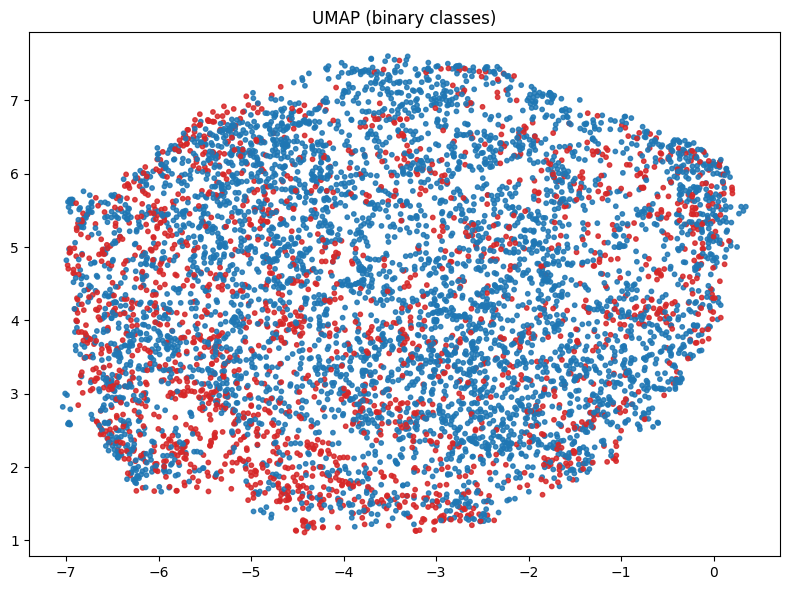

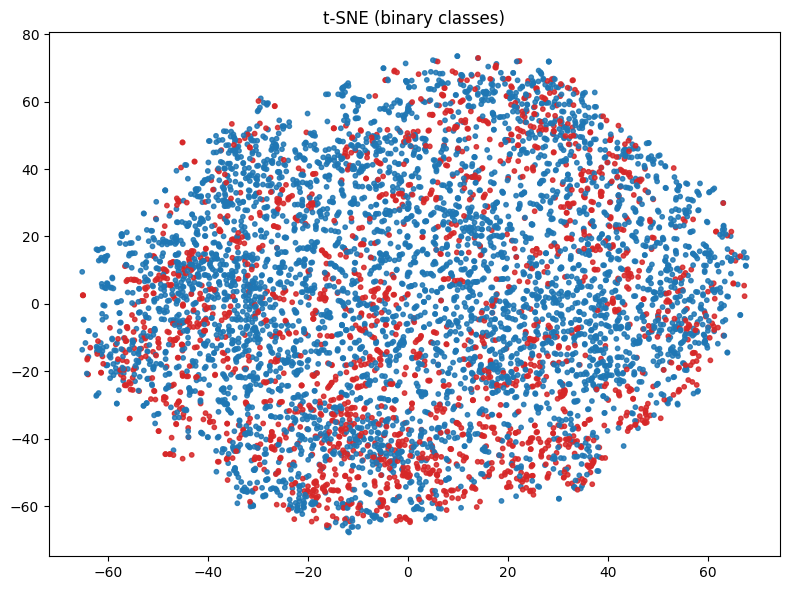

In [10]:
df_now = df_train[df_train['db'] == 1]
test_dataset = CoughDatasets(df_now.values, hps.data, wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{fold}.pickle", train=False)
test_loader = DataLoader(test_dataset, num_workers=28, shuffle=True, batch_size=hps.train.batch_size, pin_memory=True, drop_last=True, collate_fn=collate_fn)

feats_list = []
labels_list = []
metas_train = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Extracting embeddings"):
        wavnames, audio1, audio2, attention_masks, dse_ids, _ = batch
        audio1 = audio1.cuda()

        _, emb = runner_lightning.model.forward_encoder(audio1)
        labels = torch.argmax(dse_ids, dim=1)

        emb = emb.detach().cpu()
        feats_list.append(emb)
        labels_list.append(labels)
        metas_train.extend(wavnames)

X_train = torch.cat(feats_list, dim=0).numpy()
X_train = scaler.transform(X_train)
y_train = torch.cat(labels_list, dim=0).numpy()

plot_umap(X_train, y_train)
plot_tsne(X_train, y_train)

UMAP...


/run/media/fourier/Data1/Pras/Thesis_Nexus/.env_312/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


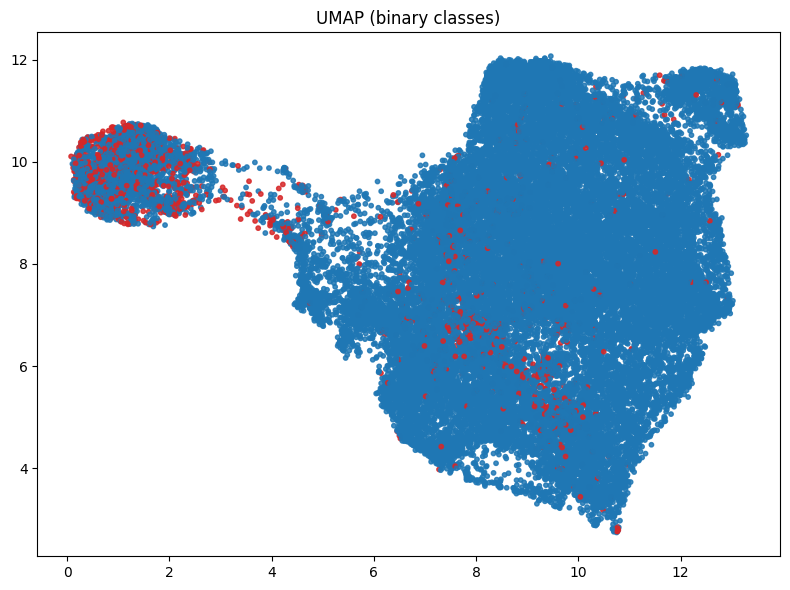

t-SNE...


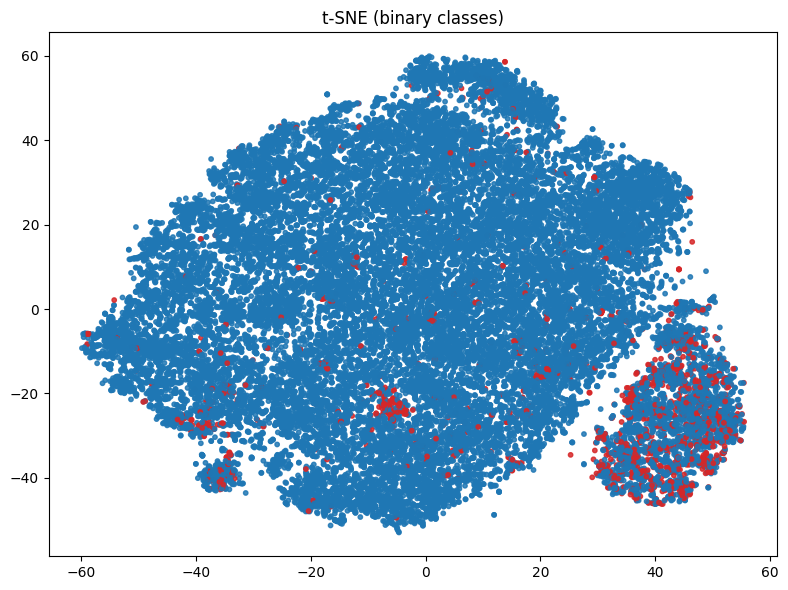

In [ ]:


# -------------------------------------------------------------
# Preprocessing
# -------------------------------------------------------------
def preprocess_embeddings(X):
    scaler = StandardScaler()
    return scaler.fit_transform(X)

# -------------------------------------------------------------
# Binary colormap
# -------------------------------------------------------------

# -------------------------------------------------------------
# Orchestrator
# -------------------------------------------------------------
def visualize_embeddings(X_test, y_test):
    X_proc = preprocess_embeddings(X_test)

    print("UMAP...")
    plot_umap(X_proc, y_test)

    print("t-SNE...")
    plot_tsne(X_proc, y_test)

# -------------------------------------------------------------
# Usage
# -------------------------------------------------------------
# visualize_embeddings(X_test, y_test)
visualize_embeddings(X_test, y_test)

In [7]:
import torch
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import silhouette_score
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim

def knn_eval(X_train, y_train, X_val, y_val, k=5):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    bal = balanced_accuracy_score(y_val, y_pred)
    p, r, f, _ = precision_recall_fscore_support(y_val, y_pred, average='weighted', zero_division=0)
    return {"acc": acc, "balanced_acc": bal, "precision": p, "recall": r, "f1": f}


In [8]:
knn = knn_eval(X_train, y_train, X_test, y_test, k=5)

In [10]:
knn

{'acc': 0.9442979371776841,
 'balanced_acc': 0.6062272456332068,
 'precision': 0.9327293136296846,
 'recall': 0.9442979371776841,
 'f1': 0.9373732494926329}